In [1931]:
import numpy as np
import pandas as pd

df = pd.read_csv('../data/data.csv')

df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [1932]:
"""
    Making Data Consistent, as some columns contain uppercases and lowercases and other underscores
"""

df.columns = df.columns.str.lower().str.replace(' ', '_') 

df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [1933]:
"""
    Making all columns of type str into consistent values 
"""

strings = list(df.dtypes[df.dtypes == 'str'].index )

strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [1934]:
for col in strings:
    df[col] = df[col] .str.lower().str.replace(' ', '_') 

df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [1935]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

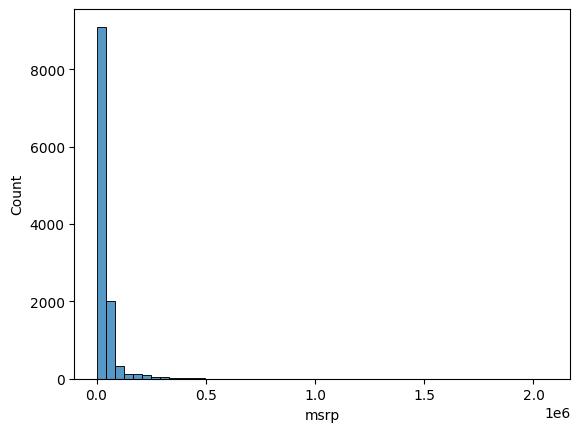

In [1936]:
sns.histplot(df.msrp, bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

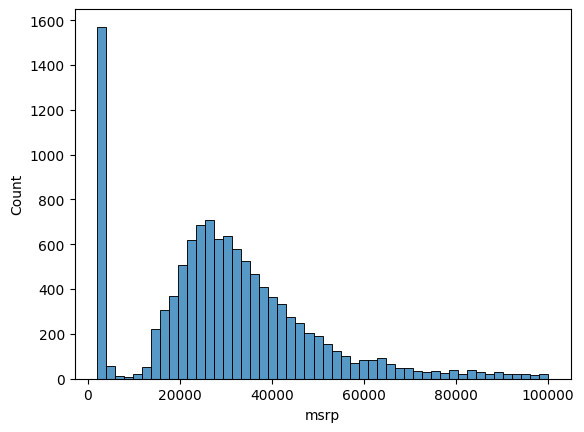

In [1937]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50)

In [1938]:

"""
    Based on the previous plots we can see that the dataset for the MSRP,
    doesent actually have a normal distribution. Instead it has a right-skewed bimodal distribution,
    so beacuse of ML Model's favorability towards
    normal distribution, we apply the natural logarithmic function to all values.
    
    In which case we get a normal distribution.
"""

price_logarithmic = np.log1p(df.msrp)

<Axes: xlabel='msrp', ylabel='Count'>

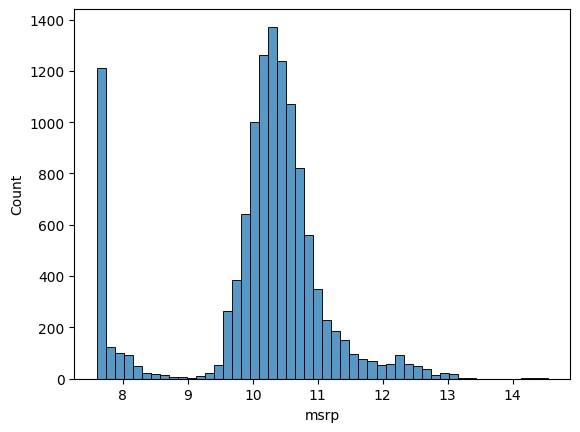

In [1939]:
sns.histplot(price_logarithmic, bins=50)

In [1940]:
"""
    The spike that we see at the beginning of the histogram is suspicious.
    Below in those couple of buckets in the range of the exponent e^x,
    where: 
    x1=7.5
    x2=8.2
    we can see we have a value of 2000 that is repeated exactly 1036 times.
    
    This almost certainly a placeholder value. One reson for this could be that those are,
    older cars where a recorded MSRP doesent exist. Lets check next where
    those 1036 records for a value of 2000 comes from.
"""



# Isolating whatever rows fall into the spike at the beginning
low_price_mask = (df['msrp'] > np.exp(7.5)) & (df['msrp'] < np.exp(8.2))
print(df[low_price_mask]['msrp'].value_counts().head(10))
print(df[low_price_mask][['make', 'model']].value_counts().head(10))

msrp
2000    1036
2107       4
2080       3
2234       3
2122       3
2078       3
3214       3
2637       3
2996       3
2066       3
Name: count, dtype: int64
make           model          
chevrolet      c/k_1500_series    53
ford           f-250              41
dodge          ram_150            40
mazda          b-series_pickup    37
chevrolet      s-10_blazer        31
mercedes-benz  300-class          27
volvo          850                26
toyota         pickup             26
dodge          ram_250            25
saab           900                23
Name: count, dtype: int64


In [1941]:
"""
    We can see that that is indeed true, the fact that those cars are older models who probably
    didnt have a recorded MSRP. We can see that 75% of the 1036 rows fall into the category of
    cars being 1995 model or earlier.
    
    With this we have a couple of options:

     -Option One:
        Is to label it as NaN and later drop all of those 1036 values
    
    - Option Two:
        Is to use `Data Imputation via model prediction`. The way to do this would be
        to find data within the dataset that is similar to the placeholder data(the 1036 values)
        and to use a model to find the approximate value for those placeholder data rows.
        
        The problem with this for our dataset is it wont be accurate. If we take a car model
        that is 2015 with similar or exact features as a car from the missing placeholder data,
        say that is 1995 model, our regression system wont take into the account other variables,
        such as inflation, branding and other variables.
        
        The other problem with this is we would be guessing with no real baseline price,
        and this could introduce later a bias/noise into the rest of the data which would
        lower the accuracy of the model overall.
        
"""


print(df[df['msrp'] == 2000]['year'].describe())

count    1036.000000
mean     1993.441120
std         2.449767
min      1990.000000
25%      1992.000000
50%      1993.000000
75%      1995.000000
max      2000.000000
Name: year, dtype: float64


In [1942]:
df.loc[df['msrp'] == 2000, 'msrp'] = np.nan

print(f"Flagged {df['msrp'].isna().sum()} rows as missing MSRP")
print(df['msrp'].isna().sum(), "out of", len(df), "total rows")

Flagged 1036 rows as missing MSRP
1036 out of 11914 total rows


In [1943]:
df_clean = df.dropna(subset=['msrp'])
print(f"Remaining rows after dropping missing MSRP: {len(df_clean)}")

Remaining rows after dropping missing MSRP: 10878


In [1944]:
print(df.isna().sum())

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                 1036
dtype: int64


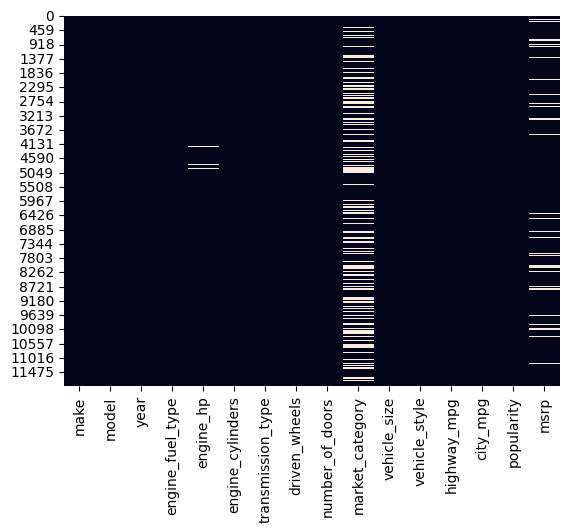

In [1945]:
sns.heatmap(df.isna(), cbar=False)
plt.show()

In [1946]:
print(df['market_category'].value_counts())
print(f"\nUnique non-null categories: {df['market_category'].nunique()}")

market_category
crossover                                          1110
flex_fuel                                           872
luxury                                              855
luxury,performance                                  673
hatchback                                           641
                                                   ... 
crossover,exotic,luxury,high-performance              1
crossover,exotic,luxury,performance                   1
exotic,luxury,high-performance,hybrid                 1
flex_fuel,factory_tuner,luxury,high-performance       1
performance,hybrid                                    1
Name: count, Length: 71, dtype: int64

Unique non-null categories: 71


In [1947]:
missing_mask = df['market_category'].isna()

# Does missingness cluster by make/brand?
print(df[missing_mask]['make'].value_counts().head(10))

# Does it cluster by year?
print(df[missing_mask]['year'].describe())

# Does it cluster by vehicle_style?
print(df[missing_mask]['vehicle_style'].value_counts().head(10))

make
chevrolet     501
toyota        443
ford          382
dodge         306
suzuki        252
gmc           245
nissan        240
volkswagen    224
honda         165
mazda         164
Name: count, dtype: int64
count    3742.000000
mean     2006.688669
std         8.732324
min      1990.000000
25%      1999.000000
50%      2008.000000
75%      2015.000000
max      2017.000000
Name: year, dtype: float64
vehicle_style
sedan                  1107
extended_cab_pickup     432
4dr_suv                 387
passenger_minivan       352
crew_cab_pickup         337
coupe                   251
wagon                   235
regular_cab_pickup      216
2dr_suv                 124
convertible             123
Name: count, dtype: int64


In [1948]:
"""
    Beacuse of missingnes not having any direct relationship between the above explored
    features, we will move on with organizing the data values appropriatley.
    We can se from the prvious two blocks that for market_category there exists 71 unique values
    of which some are repeated, and an uneven distribution to say as there are a lot of values for:
    
    crossover                                          1110
    flex_fuel                                           872
    luxury                                              855
    luxury,performance                                  673
    hatchback                                           641
        
    and a small amount of:
    
    crossover,exotic,luxury,high-performance              1
    crossover,exotic,luxury,performance                   1
    exotic,luxury,high-performance,hybrid                 1
    flex_fuel,factory_tuner,luxury,high-performance       1
    performance,hybrid                                    1
    
    beacuse of this we will create new features where
"""


df['market_category'] = df['market_category'].fillna('unknown')
all_tags = set()
for entry in df['market_category'].str.split(','):
    all_tags.update(entry)

for tag in all_tags:
    df[f'tag_{tag}'] = df['market_category'].str.contains(tag).astype(int)
    
    
print([c for c in df.columns if c.startswith('tag_')])
df.filter(like='tag_').sum().sort_values(ascending=False)

['tag_performance', 'tag_luxury', 'tag_flex_fuel', 'tag_hatchback', 'tag_diesel', 'tag_hybrid', 'tag_high-performance', 'tag_factory_tuner', 'tag_exotic', 'tag_crossover', 'tag_unknown']


tag_unknown             3742
tag_performance         3501
tag_luxury              3288
tag_crossover           2034
tag_high-performance    1387
tag_hatchback           1208
tag_flex_fuel           1197
tag_factory_tuner        621
tag_exotic               501
tag_hybrid               347
tag_diesel               206
dtype: int64

In [1949]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,...,tag_luxury,tag_flex_fuel,tag_hatchback,tag_diesel,tag_hybrid,tag_high-performance,tag_factory_tuner,tag_exotic,tag_crossover,tag_unknown
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",...,1,0,0,0,0,1,1,0,0,0
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",...,1,0,0,0,0,0,0,0,0,0
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",...,1,0,0,0,0,1,0,0,0,0
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",...,1,0,0,0,0,0,0,0,0,0
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,...,1,0,0,0,0,0,0,0,0,0


In [1950]:
tag_cols = ['tag_performance', 'tag_luxury', 'tag_flex_fuel', 'tag_hatchback', 'tag_diesel',
            'tag_hybrid', 'tag_high-performance', 'tag_factory_tuner', 'tag_exotic', 'tag_crossover', 'tag_unknown']
print(df[tag_cols].corr())

                      tag_performance  tag_luxury  tag_flex_fuel  \
tag_performance              1.000000    0.320203      -0.100976   
tag_luxury                   0.320203    1.000000      -0.118266   
tag_flex_fuel               -0.100976   -0.118266       1.000000   
tag_hatchback               -0.005480   -0.143313      -0.105787   
tag_diesel                  -0.085568    0.040548      -0.010060   
tag_hybrid                  -0.079955    0.010313      -0.051243   
tag_high-performance         0.562685    0.236653      -0.070819   
tag_factory_tuner            0.361856    0.156804      -0.060785   
tag_exotic                   0.313770    0.066176      -0.036635   
tag_crossover               -0.168312    0.043247      -0.087823   
tag_unknown                 -0.436524   -0.417781      -0.226151   

                      tag_hatchback  tag_diesel  tag_hybrid  \
tag_performance           -0.005480   -0.085568   -0.079955   
tag_luxury                -0.143313    0.040548    0.0103

In [1951]:
"""
    Upon searching for evidence for correlation between the feature tags we have found
    a high enough correlation to flag between tag_high_performance and tag_performance @ 0.562685
    This is a high enough correlation to investigate.
    
    With the code down below we check wether every high_performance tagged car also shows tag_perfromance
    and the answer is yes, the two are directly related as the totatl amount of tag_high_performance,
    appears 1387 times withing tag_performance which totals 3501.
    
    Thus we can drop tah_high_performance and continue with only tag_performance.
    
    IMPORTANT: Later we actually discover that ist just a regex matching bug, and that there
    is no real correlation. However if it were read the following:
    
    This is done in order to drop unnecesary noise as part of the EDA on this dataset.
    
    Altough this part could also be fixed by using L1 regularization which is sure to drive,
    the impact of this feature very low(possibly even ~0) as it already is.
    
    Note: the mention for saying that its showing high correlation even though its at 0.562685
    which arguably is not that significant is beacuse before we found out that the feature is redundant
    and actually very highly corellated we got a value of 0.562685 simply due to the difference of size between
    the two features.
    tag_performance: 3501
    tag_high_performance: 1387
    
    Finding:
    correlation coefficients can understate a real structural bug when group sizes are uneven,
    thus we shouldnt rely on magnituted alone.
"""



# Direct test: does every high-performance row also show tag_performance=1?
hp_rows = df[df['tag_high-performance'] == 1]
print(hp_rows['tag_performance'].value_counts())

tag_performance
1    1387
Name: count, dtype: int64


In [1952]:
import re

df['market_category'] = df['market_category'].fillna('Unknown')

all_tags = set()
for entry in df['market_category'].str.split(','):
    all_tags.update(entry)

for tag in all_tags:
    pattern = rf'(?:^|,){re.escape(tag)}(?:,|$)'
    df[f'tag_{tag}'] = df['market_category'].str.contains(pattern, regex=True).astype(int)

In [1953]:

# NO CORRELATION
hp_rows = df[df['tag_high-performance'] == 1]
print(hp_rows['tag_performance'].value_counts())

tag_performance
0    1387
Name: count, dtype: int64


In [1954]:
df_model = df.drop(columns=['market_category'])

df_model.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,vehicle_size,...,tag_luxury,tag_flex_fuel,tag_hatchback,tag_diesel,tag_hybrid,tag_high-performance,tag_factory_tuner,tag_exotic,tag_crossover,tag_unknown
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,compact,...,1,0,0,0,0,1,1,0,0,0
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,compact,...,1,0,0,0,0,0,0,0,0,0
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,compact,...,1,0,0,0,0,1,0,0,0,0
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,compact,...,1,0,0,0,0,0,0,0,0,0
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,compact,...,1,0,0,0,0,0,0,0,0,0


In [1955]:
numeric_cols = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity', 'year']


df_model[numeric_cols].describe()

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity,year
count,11845.00000,11884.000000,11914.000000,11914.000000,11914.000000,11914.000000
mean,249.38607,5.628829,26.637485,19.733255,1554.911197,2010.384338
std,109.19187,1.780559,8.863001,8.987798,1441.855347,7.579740
min,55.00000,0.000000,12.000000,7.000000,2.000000,1990.000000
25%,170.00000,4.000000,22.000000,16.000000,549.000000,2007.000000
50%,227.00000,6.000000,26.000000,18.000000,1385.000000,2015.000000
75%,300.00000,6.000000,30.000000,22.000000,2009.000000,2016.000000
max,1001.00000,16.000000,354.000000,137.000000,5657.000000,2017.000000


<Axes: xlabel='engine_hp', ylabel='Count'>

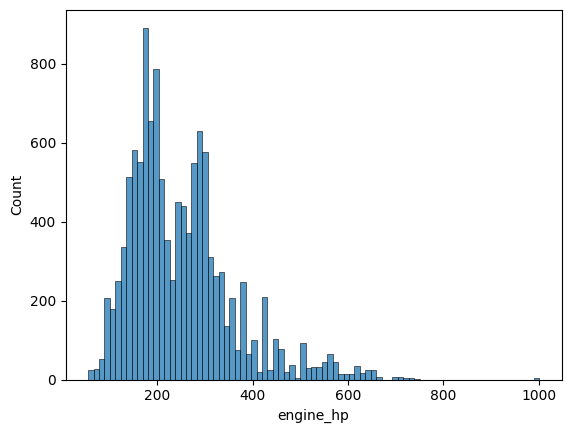

In [1956]:
sns.histplot(df_model.engine_hp)

<Axes: xlabel='log_engine_hp', ylabel='Count'>

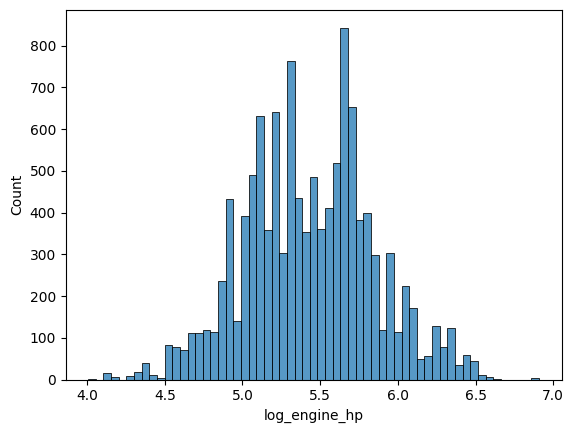

In [1957]:
"""
    We can see that this is also right-skewed distribution,
    For this we will employ a log transformation.
    
    The data for this is relatively expected, most cars are consumer general everyday use cars 
    and the data supports this as most are clustered between 100-200, then a smaller amount pushing
    200+, and a handful of extreme(the bar at 1000)
"""

df_model['log_engine_hp'] = np.log(df_model['engine_hp'])

sns.histplot(df_model.log_engine_hp)

In [1958]:
def skew(a):
    return ((a - a.mean())**3).mean() / a.std()**3

print("Raw skew:", skew(df['engine_hp']))
print("Log skew:", skew(np.log(df['engine_hp'])))


"""
    We have effectively reduced the skew by ~1.24
"""


Raw skew: 1.2909028001077958
Log skew: 0.058248663767137596


'\n    We have effectively reduced the skew by ~1.24\n'

<Axes: xlabel='highway_mpg', ylabel='Count'>

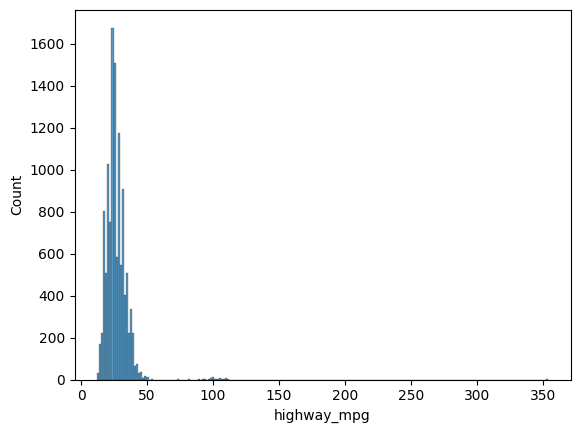

In [1959]:
"""
    What follows below is a discovery of outlier rows with a typo and fixing it
    and a logarithmic function being applied to the highway mpg
    in order to get a normal distribution
"""


sns.histplot(df['highway_mpg'])

In [1960]:
df_model['highway_mpg'].describe()

count    11914.000000
mean        26.637485
std          8.863001
min         12.000000
25%         22.000000
50%         26.000000
75%         30.000000
max        354.000000
Name: highway_mpg, dtype: float64

In [1961]:
print(df[df['highway_mpg'] > 60][['make', 'model', 'year', 'highway_mpg', 'engine_fuel_type']].sort_values('highway_mpg', ascending=False))

               make                   model  year  highway_mpg  \
1119           audi                      a6  2017          354   
5790            bmw                      i3  2015          111   
5792            bmw                      i3  2017          111   
5791            bmw                      i3  2016          111   
1983      chevrolet                 bolt_ev  2017          110   
...             ...                     ...   ...          ...   
1681  mercedes-benz  b-class_electric_drive  2016           82   
1680  mercedes-benz  b-class_electric_drive  2015           82   
8373         toyota                 rav4_ev  2012           74   
8374         toyota                 rav4_ev  2013           74   
8375         toyota                 rav4_ev  2014           74   

                    engine_fuel_type  
1119  premium_unleaded_(recommended)  
5790                        electric  
5792                        electric  
5791                        electric  
1983        

In [1962]:
# Are there other Audi A6 rows (different years/trims) to cross-reference?
print(df[(df['make'] == 'audi') & (df['model'] == 'a6')][['year', 'highway_mpg', 'engine_fuel_type']])

      year  highway_mpg                engine_fuel_type
1098  2015           38                          diesel
1099  2015           29  premium_unleaded_(recommended)
1100  2015           33  premium_unleaded_(recommended)
1101  2015           27     premium_unleaded_(required)
1102  2015           33  premium_unleaded_(recommended)
1103  2015           27     premium_unleaded_(required)
1104  2015           29  premium_unleaded_(recommended)
1105  2015           38                          diesel
1106  2016           32  premium_unleaded_(recommended)
1107  2016           35  premium_unleaded_(recommended)
1108  2016           35  premium_unleaded_(recommended)
1109  2016           38                          diesel
1110  2016           30     premium_unleaded_(required)
1111  2016           30     premium_unleaded_(required)
1112  2016           38                          diesel
1113  2016           32  premium_unleaded_(recommended)
1114  2017           31  premium_unleaded_(recom

In [1963]:
df_model['highway_mpg'] = df_model['highway_mpg'].astype(float)
df_model.loc[df['highway_mpg'] > 200, 'highway_mpg'] = df_model.loc[df_model['highway_mpg'] > 200, 'highway_mpg'] / 10

In [1964]:
print(df_model['highway_mpg'].dtype)
print(df_model.loc[1119, 'highway_mpg'])
print(df_model['highway_mpg'].describe())

float64
35.4
count    11914.000000
mean        26.610744
std          8.340430
min         12.000000
25%         22.000000
50%         26.000000
75%         30.000000
max        111.000000
Name: highway_mpg, dtype: float64


Raw skew: 4.020730216630562
Log skew: 0.6621421744578242


<Axes: xlabel='log_highway_mpg', ylabel='Count'>

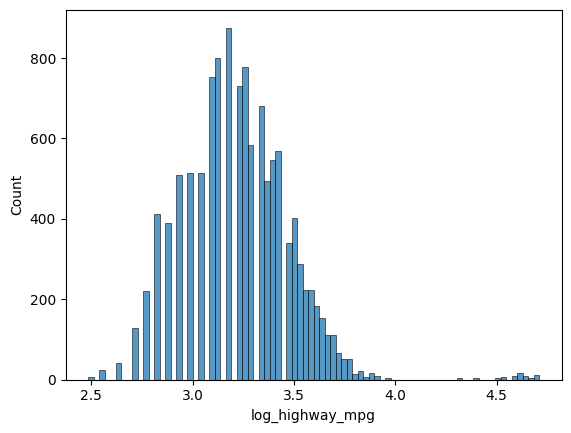

In [1965]:
def skew(a):
    return ((a - a.mean())**3).mean() / a.std()**3

print("Raw skew:", skew(df_model['highway_mpg'].dropna()))

df_model['log_highway_mpg'] = np.log(df_model['highway_mpg'])
print("Log skew:", skew(df_model['log_highway_mpg'].dropna()))

sns.histplot(df_model.log_highway_mpg)

In [1966]:
df_model = df_model.drop(columns=['highway_mpg'])

<p style="text-align: center;">
<img src='../images/IQR.png'>
</p>

In [1967]:
def check_outliers(df, col, context_cols=['make', 'model', 'year', 'engine_fuel_type']):
    """
    This is a function that flags statistical outliers
    in a numeric column using the IQR method,
    and prints them alongside context columns so you can judge
    'real outlier' vs 'data error' rather than just deleting blindly.
    """
    
    # getting the correct variables
    series = df[col].dropna()
    k=1.5
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    
    # looking for otuliers between the upper and lower bound of the iqr
    # Any observations that are more than 1.5 IQR below Q1 or more than 1.5 IQR above Q3 are considered outliers
    mask = (df[col] < lower) | (df[col] > upper)
    outliers = df.loc[mask, [col] + context_cols].sort_values(col, ascending=False)
    
    print(f"'{col}': bounds = [{lower:.3f}, {upper:.3f}]")
    print(f"Found {mask.sum()} outliers out of {len(df)} rows ({100*mask.sum()/len(df):.1f}%)")
    print(outliers.head(15))
    
    return outliers

In [1968]:
outliers = check_outliers(df_model, 'log_highway_mpg')

'log_highway_mpg': bounds = [2.626, 3.866]
Found 129 outliers out of 11914 rows (1.1%)
      log_highway_mpg       make     model  year engine_fuel_type
5790         4.709530        bmw        i3  2015         electric
5792         4.709530        bmw        i3  2017         electric
5791         4.709530        bmw        i3  2016         electric
1983         4.700480  chevrolet   bolt_ev  2017         electric
1984         4.700480  chevrolet   bolt_ev  2017         electric
9872         4.691348  chevrolet  spark_ev  2016         electric
9871         4.691348  chevrolet  spark_ev  2016         electric
9870         4.691348  chevrolet  spark_ev  2015         electric
9869         4.691348  chevrolet  spark_ev  2015         electric
9868         4.691348  chevrolet  spark_ev  2014         electric
9867         4.691348  chevrolet  spark_ev  2014         electric
539          4.682131       fiat      500e  2015         electric
6936         4.672829      tesla   model_s  2016       

In [1969]:
outliers = check_outliers(df_model, 'log_highway_mpg')
print(outliers.tail(10))  # the lowest flagged values, not just the highest

'log_highway_mpg': bounds = [2.626, 3.866]
Found 129 outliers out of 11914 rows (1.1%)
      log_highway_mpg       make     model  year engine_fuel_type
5790         4.709530        bmw        i3  2015         electric
5792         4.709530        bmw        i3  2017         electric
5791         4.709530        bmw        i3  2016         electric
1983         4.700480  chevrolet   bolt_ev  2017         electric
1984         4.700480  chevrolet   bolt_ev  2017         electric
9872         4.691348  chevrolet  spark_ev  2016         electric
9871         4.691348  chevrolet  spark_ev  2016         electric
9870         4.691348  chevrolet  spark_ev  2015         electric
9869         4.691348  chevrolet  spark_ev  2015         electric
9868         4.691348  chevrolet  spark_ev  2014         electric
9867         4.691348  chevrolet  spark_ev  2014         electric
539          4.682131       fiat      500e  2015         electric
6936         4.672829      tesla   model_s  2016       

Raw skew: 7.104891311393222
Log skew: 1.4199016041975414
'log_city_mpg': bounds = [2.295, 3.569]
Found 288 outliers out of 11914 rows (2.4%)
      log_city_mpg       make     model  year engine_fuel_type
5791      4.919981        bmw        i3  2016         electric
5792      4.919981        bmw        i3  2017         electric
5790      4.919981        bmw        i3  2015         electric
4706      4.882802      honda    fit_ev  2014         electric
4705      4.882802      honda    fit_ev  2013         electric
5793      4.859812        bmw        i3  2017         electric
1983      4.852030  chevrolet   bolt_ev  2017         electric
9869      4.852030  chevrolet  spark_ev  2015         electric
9867      4.852030  chevrolet  spark_ev  2014         electric
9868      4.852030  chevrolet  spark_ev  2014         electric
1984      4.852030  chevrolet   bolt_ev  2017         electric
9870      4.852030  chevrolet  spark_ev  2015         electric
9872      4.852030  chevrolet  spark_ev 

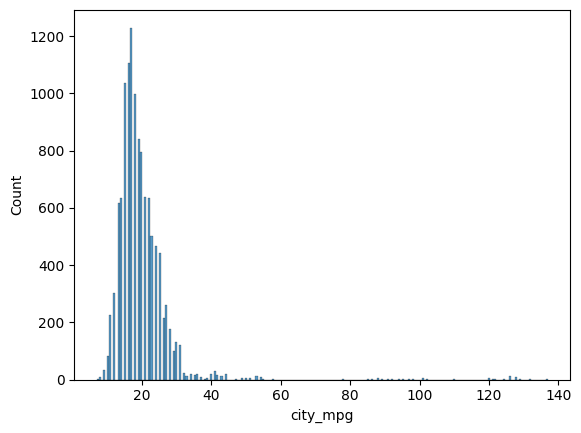

In [1970]:
sns.histplot(df_model['city_mpg'])
print("Raw skew:", skew(df_model['city_mpg'].dropna()))

df_model['log_city_mpg'] = np.log(df_model['city_mpg'])
print("Log skew:", skew(df_model['log_city_mpg'].dropna()))

outliers_city = check_outliers(df_model, 'log_city_mpg')
print(outliers_city.head(15))   # high end
print(outliers_city.tail(10))   # low end

In [1971]:
df_model = df_model.drop(columns=['city_mpg'])

In [1972]:
"""
    Data imputation by Model for the missing 68 rows for engine_hp
    then whatever is left we drop if its still NAN
"""


df_model['engine_hp'] = df_model.groupby(['make', 'model'])['engine_hp'].transform(
    lambda x: x.fillna(x.median())
)

# Catch any still-missing (e.g. a make/model with ALL rows missing HP, so no group median exists)
remaining_missing = df_model['engine_hp'].isna().sum()
print(f"Still missing after group-median fill: {remaining_missing}")
if remaining_missing > 0:
    df_model['engine_hp'] = df_model['engine_hp'].fillna(df_model['engine_hp'].median())

df_model = df_model.dropna(subset=['engine_hp'])

Still missing after group-median fill: 38


In [1973]:
df_model.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,vehicle_size,...,tag_diesel,tag_hybrid,tag_high-performance,tag_factory_tuner,tag_exotic,tag_crossover,tag_unknown,log_engine_hp,log_highway_mpg,log_city_mpg
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,compact,...,0,0,1,1,0,0,0,5.814131,3.258097,2.944439
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,compact,...,0,0,0,0,0,0,0,5.703782,3.332205,2.944439
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,compact,...,0,0,1,0,0,0,0,5.703782,3.332205,2.995732
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,compact,...,0,0,0,0,0,0,0,5.438079,3.332205,2.890372
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,compact,...,0,0,0,0,0,0,0,5.438079,3.332205,2.890372


In [1976]:
"""
    Full Preprocessing + Model Training Pipeline
    
    This runs the complete cleaning pipeline from the raw dataframe through to a trained model.
    Every stage handles one specific data problem that was identified during EDA:
    - msrp had a placeholder value of 2000 for all cars from 1990-2000 (treated as missing, dropped)
    - market_category was a compound comma-separated string (split into binary tag columns)
    - engine_hp had missing values (filled via make/model median, then electric median fallback)
    - engine_cylinders was structurally missing for rotary and electric engines (filled with 0)
    - highway_mpg had a single data entry error (354 instead of 35.4)
    - highway_mpg, city_mpg, engine_hp, popularity and msrp were all right-skewed (log-transformed)
    
    The target is log_msrp, so predictions come back in log space and must be exponentiated
    with np.exp() to get real dollar values.
    
    Note: The preprocessing code down below is generated by Claude,
    the reason for this is after the personal EDA to get a structured baseline,
    with the gradient desecnt, and polynomial regression models that are hand implemented
    by me from other notebooks. The baseline is later used to measure it against other
    hand implemented models and hyperparamaters and actual libraries like Scikit.
    
"""

df.columns = df.columns.str.lower().str.replace(' ', '_')
df_model = df.copy()


"""
    msrp: The value 2000 appeared 1036 times, and every single one of those rows falls between 1990-2000.
    This isn't a real price, it's a placeholder for cars where the MSRP was never actually recorded.
    We mark it as NaN to be honest about it being missing, then drop those rows since msrp is our target
    and a model can't learn from a missing target. Then we log it since it's heavily right skewed.
"""
df_model.loc[df_model['msrp'] == 2000, 'msrp'] = np.nan
df_model = df_model.dropna(subset=['msrp'])
df_model['log_msrp'] = np.log(df_model['msrp'])


"""
    market_category: This is a compound comma-separated string like "luxury,performance".
    There are 71 unique combinations, but only about 11 unique individual tags, so instead of one-hot
    encoding all 71 combos (which would give us a huge sparse matrix with near-unique columns),
    we split each string into its individual tags and make one binary column per tag.
    
    The regex uses word boundaries `(?:^|,)tag(?:,|$)` instead of a plain substring match,
    otherwise `str.contains('performance')` would also falsely match `high-performance`.
"""
df_model['market_category'] = df_model['market_category'].fillna('Unknown')

all_tags = set()
for entry in df_model['market_category'].str.split(','):
    all_tags.update(entry)

for tag in all_tags:
    pattern = rf'(?:^|,){re.escape(tag)}(?:,|$)'
    df_model[f'tag_{tag}'] = df_model['market_category'].str.contains(pattern, regex=True).astype(int)

df_model = df_model.drop(columns=['market_category'])


"""
    engine_hp: 69 missing values, mostly electric cars (Tesla, Nissan Leaf, Kia Soul EV).
    Electric cars DO have a real horsepower rating, it just wasn't recorded here, so this is a
    genuine data gap and not something structural.
    
    We fill it using the median horsepower of the same make+model group, since horsepower varies
    massively between vehicle types and a dataset-wide average would be a terrible guess.
    For the groups where every single row is missing (like Tesla Model S), there's no group median
    to compute, so we fall back to the median of all other electric cars.
"""
df_model['engine_hp'] = df_model.groupby(['make', 'model'])['engine_hp'].transform(
    lambda x: x.fillna(x.median())
)

electric_median_hp = df_model.loc[df_model['engine_fuel_type'] == 'electric', 'engine_hp'].median()
df_model['engine_hp'] = df_model['engine_hp'].fillna(electric_median_hp)
df_model = df_model.dropna(subset=['engine_hp'])

df_model['log_engine_hp'] = np.log(df_model['engine_hp'])


"""
    engine_cylinders: 30 missing values, and every single one is either a Mazda RX-7/RX-8 (rotary engine)
    or an electric car. Neither of these have piston cylinders at all, so this isn't missing data
    in the "we don't know" sense, the concept just doesn't apply to them.
    
    Filling with 0 here is not a placeholder trick like the msrp=2000 case was, it's literally true.
"""
df_model['engine_cylinders'] = df_model['engine_cylinders'].fillna(0)


"""
    highway_mpg / city_mpg: One row (a 2017 Audi A6) had highway_mpg = 354, which is impossible for a
    gasoline car. Every other Audi A6 from 2015-2017 sits between 29-35 mpg, so this is a decimal point
    that got dropped during data entry (35.4 became 354). Dividing by 10 lands it right back in the cluster.
    
    The remaining high outliers (BMW i3, Chevy Bolt, Tesla) are all legitimate electric cars with real
    MPGe ratings, and the low outliers are trucks and supercars, so both tails are real and stay untouched.
    Both columns get logged since the EV cluster drags the skew way up (raw skew was 4+).
"""
df_model['highway_mpg'] = df_model['highway_mpg'].astype(float)
df_model.loc[df_model['highway_mpg'] > 200, 'highway_mpg'] = df_model.loc[df_model['highway_mpg'] > 200, 'highway_mpg'] / 10

df_model['log_highway_mpg'] = np.log(df_model['highway_mpg'])
df_model['log_city_mpg'] = np.log(df_model['city_mpg'])
df_model = df_model.drop(columns=['highway_mpg', 'city_mpg'])


"""
    number_of_doors: Only 6 missing values, and 70% of all cars in the dataset have 4 doors.
    With this few missing and such a dominant mode, filling with the most common value is safe.
"""
df_model['number_of_doors'] = df_model['number_of_doors'].fillna(df_model['number_of_doors'].mode()[0])


"""
    popularity: Right skewed (skew of 1.65), so it gets the same log treatment as the other skewed columns.
    
    year: Left as-is on purpose. It's a calendar value, not a magnitude, so "log of a year" is meaningless.
    A 2017 car isn't "1.001x" a 2015 car in any way that logging would capture, the relationship is linear.
"""
df_model['log_popularity'] = np.log(df_model['popularity'])
df_model = df_model.drop(columns=['popularity'])


"""
    Categorical Encoding:
    
    The low cardinality columns (a handful of unique values each) get one-hot encoded. We use drop_first=True
    to avoid the dummy variable trap, where one column is perfectly predictable from the others and the
    model can't cleanly separate their coefficients.
    
    `make` has ~48 unique brands which is too many for clean one-hot encoding, so it gets frequency encoded
    (each brand replaced by how many times it appears in the dataset).
    
    `model` has hundreds of unique values and gets dropped entirely, since make + the engine/body specs
    already capture most of the signal a specific model name would give us.
"""
low_card_cols = ['engine_fuel_type', 'transmission_type', 'driven_wheels', 'vehicle_size', 'vehicle_style']
df_model = pd.get_dummies(df_model, columns=low_card_cols, drop_first=True)

make_freq = df_model['make'].value_counts()
df_model['make_freq'] = df_model['make'].map(make_freq)
df_model = df_model.drop(columns=['make', 'model'])


"""
    Assembling the final feature matrix X and target vector y.
    
    We drop the raw msrp (that's our target, keeping it would be data leakage), log_msrp (it IS the target),
    and raw engine_hp (we kept the logged version instead).
    
    The assertions at the end are there because NaN and inf propagate SILENTLY through gradient descent
    instead of crashing. One log(0) anywhere in the data turns into -inf, which turns every weight into NaN
    on the very first update, and then the loss just prints "nan" for 2000 iterations with no error.
    Better to catch it here at the boundary than to debug it after the fact.
"""
y = df_model['log_msrp'].values.reshape(-1, 1)
X_df = df_model.drop(columns=['msrp', 'log_msrp', 'engine_hp']).astype(float)
feature_names = X_df.columns.tolist()
X = X_df.values

print(f"Final shape: X={X.shape}, y={y.shape}, features={len(feature_names)}")

assert not np.isnan(X).any(), "X contains NaN"
assert not np.isinf(X).any(), "X contains inf"
assert not np.isnan(y).any(), "y contains NaN"
assert not np.isinf(y).any(), "y contains inf -- check for log(0)"
print("Data integrity checks passed.")


"""
    Train/Test Split + Standardization (80/20 split).
    
    The mean and std used for standardization are computed on the TRAINING set only, then applied to both
    train and test. If we computed them on the full dataset, information from the test set would leak into
    the training process, and our test score would be optimistically wrong.
    
    Any column with std of 0 (a constant column) would cause a divide-by-zero, so those get set to 1.
"""
np.random.seed(42)
idx = np.random.permutation(len(X))
split = int(0.8 * len(X))
train_idx, test_idx = idx[:split], idx[split:]

X_train_raw, X_test_raw = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

X_mean, X_std = X_train_raw.mean(axis=0), X_train_raw.std(axis=0)
X_std[X_std == 0] = 1
X_train = (X_train_raw - X_mean) / X_std
X_test = (X_test_raw - X_mean) / X_std

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


"""
    Training with the hand-implemented L2 (Ridge) gradient descent.
    
    This is the same gradient_descent_L2 from the regularization notebook, the L2 penalty term
    (2 * lambda_L2 * W) gets added directly to the weight gradient, which shrinks all weights
    smoothly toward zero without ever forcing any of them to exactly 0.
"""
def polynomial_regression(X, W, b):
    return np.dot(X, W) + b

def gradient_descent_L2(X, y, W, b, learning_rate, num_iterations, lambda_L2):
    m = len(y)
    for i in range(num_iterations):
        y_pred = polynomial_regression(X, W, b)
        dW = (2/m) * np.dot(X.T, (y_pred - y)) + 2 * lambda_L2 * W
        db = (2/m) * np.sum(y_pred - y)
        W -= learning_rate * dW
        b -= learning_rate * db
        if i % 200 == 0:
            print(f"Iteration {i}: MSE (log-space) = {np.mean((y_pred - y)**2):.4f}")
    return W, b

W = np.zeros((X_train.shape[1], 1))
b = 0.0
W_final, b_final = gradient_descent_L2(X_train, y_train, W, b, learning_rate=0.05, num_iterations=2000, lambda_L2=0.01)


"""
    Evaluation in both log space and real dollar space.
    
    The MSE we train on lives in LOG space, which is not human readable (an MSE of 0.23 doesn't tell you
    anything about dollars). So we exponentiate the predictions back with np.exp() to get real prices,
    then measure:
    
    - MAE (Mean Absolute Error): average dollar amount we're off by
    - MAPE (Mean Absolute Percentage Error): average percentage we're off by, which is more meaningful here
      since being $5000 off on a $20k car is much worse than being $5000 off on a $200k car
"""
y_pred_test_log = polynomial_regression(X_test, W_final, b_final)
print(f"\nTest MSE (log space): {np.mean((y_pred_test_log - y_test)**2):.4f}")

y_pred_dollars = np.exp(y_pred_test_log)
y_test_dollars = np.exp(y_test)

print(f"Test MAE: ${np.mean(np.abs(y_pred_dollars - y_test_dollars)):,.2f}")
print(f"Test MAPE: {np.mean(np.abs((y_pred_dollars - y_test_dollars)/y_test_dollars))*100:.2f}%")

print("\nSample predictions vs actual:")
for i in range(10):
    print(f"  Predicted: ${y_pred_dollars[i][0]:>10,.0f}   Actual: ${y_test_dollars[i][0]:>10,.0f}")

Final shape: X=(10878, 52), y=(10878, 1), features=52
Data integrity checks passed.
Train shape: (8702, 52), Test shape: (2176, 52)
Iteration 0: MSE (log-space) = 107.7925
Iteration 200: MSE (log-space) = 0.1450
Iteration 400: MSE (log-space) = 0.1443
Iteration 600: MSE (log-space) = 0.1441
Iteration 800: MSE (log-space) = 0.1441
Iteration 1000: MSE (log-space) = 0.1440
Iteration 1200: MSE (log-space) = 0.1440
Iteration 1400: MSE (log-space) = 0.1440
Iteration 1600: MSE (log-space) = 0.1440
Iteration 1800: MSE (log-space) = 0.1440

Test MSE (log space): 0.1520
Test MAE: $11,506.98
Test MAPE: 31.37%

Sample predictions vs actual:
  Predicted: $    11,783   Actual: $    22,185
  Predicted: $    95,190   Actual: $   182,700
  Predicted: $    27,632   Actual: $    17,190
  Predicted: $    27,016   Actual: $    21,695
  Predicted: $   138,063   Actual: $   120,440
  Predicted: $    63,462   Actual: $    91,875
  Predicted: $    16,527   Actual: $    22,335
  Predicted: $    21,328   Actual: